## Assignment 03 _ Pie

**Author** - Alec Reid

**Date** - 03.11.2025

----


**Taks**

Create a notebook called assignment03-pie.ipynb

The note book should have a nice pie chart of peoples email domains in the csv file at the url

https://drive.google.com/uc?id=1AWPf-pJodJKeHsARQK_RHiNsE8fjPCVK&export=download

This csv file has 1000 people. You may download the data or link to it.

Marks will be given for:

- Just creating the pie chart
- Making it look nice

As always your code should be well laid out.

If you are having difficulties, know I will be doing more on Pie charts later in this module.

------

Resources:
- Faramarzi, M. (2024, February 26). Basics of accessing data from URLs using Pandas [Kaggle Notebook]. Kaggle. https://www.kaggle.com/code/masoudfaramarzi/basics-of-accesing-data-from-urls-using-pandas
- 

#### 1. Get a Summary of the Data Contained in the URL

In [ ]:
# Imports
import pandas as pd

# URL of the dataset
url = "https://drive.google.com/uc?id=1AWPf-pJodJKeHsARQK_RHiNsE8fjPCVK&export=download"

# Load the dataset from the URL
data = pd.read_csv(url)

# Display dataset information
data.info()

# Display statistical summary of the columns
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Index          1000 non-null   int64 
 1   User Id        1000 non-null   object
 2   First Name     1000 non-null   object
 3   Last Name      1000 non-null   object
 4   Sex            1000 non-null   object
 5   Email          1000 non-null   object
 6   Phone          1000 non-null   object
 7   Date of birth  1000 non-null   object
 8   Job Title      1000 non-null   object
dtypes: int64(1), object(8)
memory usage: 70.4+ KB
             Index
count  1000.000000
mean    500.500000
std     288.819436
min       1.000000
25%     250.750000
50%     500.500000
75%     750.250000
max    1000.000000


In [31]:
# Show the first 5 roews of the URL
data.head(5)

,Index,User Id,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Domain
0,1,8717bbf45cCDbEe,Shelia,Mahoney,Male,pwarner@example.org,857.139.8239,2014-01-27,Probation officer,example.org
1,2,3d5AD30A4cD38ed,Jo,Rivers,Female,fergusonkatherine@example.net,+1-950-759-8687,1931-07-26,Dancer,example.net
2,3,810Ce0F276Badec,Sheryl,Lowery,Female,fhoward@example.org,(599)782-0605,2013-11-25,Copy,example.org
3,4,BF2a889C00f0cE1,Whitney,Hooper,Male,zjohnston@example.com,+1-939-130-6258,2012-11-17,Counselling psychologist,example.com
4,5,9afFEafAe1CBBB9,Lindsey,Rice,Female,elin@example.net,(390)417-1635x3010,1923-04-15,Biomedical engineer,example.net


In [32]:
# Show the last 5 rows of the URL
data.tail(5)

,Index,User Id,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Domain
995,996,fedF4c7Fd9e7cFa,Kurt,Bryant,Female,lyonsdaisy@example.net,021.775.2933,1959-01-05,Personnel officer,example.net
996,997,ECddaFEDdEc4FAB,Donna,Barry,Female,dariusbryan@example.com,001-149-710-7799x721,2001-10-06,Education administrator,example.com
997,998,2adde51d8B8979E,Cathy,Mckinney,Female,georgechan@example.org,+1-750-774-4128x33265,1918-05-13,Commercial/residential surveyor,example.org
998,999,Fb2FE369D1E171A,Jermaine,Phelps,Male,wanda04@example.net,(915)292-2254,1971-08-31,Ambulance person,example.net
999,1000,8b756f6231DDC6e,Lee,Tran,Female,deannablack@example.org,079.752.5424x67259,1947-01-24,"Nurse, learning disability",example.org


**Note to Self** 

Alright, I learned from this that there is a deidicated row the domain so I don't need to muck about with email. 

----------

#### 2. Show all the Domain Names for the Emails contained in the URL 

In [22]:
unique_domains = data['Domain'].unique()
print(unique_domains)

['example.org' 'example.net' 'example.com']


In [ ]:
# Extract domain names from the Email column (If we didn't already have a Domain column)
data['Domain'] = data['Email'].str.split('@').str[1]

# Display the unique domain names
print(data['Domain'].unique())

['example.org' 'example.net' 'example.com']


In [26]:
# Count the occurrences of each domain
domain_counts = data['Domain'].value_counts()
print(domain_counts)

Domain
example.org    341
example.com    339
example.net    320
Name: count, dtype: int64


**Note to Self** 

So there are only 3 domain names and about 300 entries for each which means it should be easy enough to make a neat pie chart 

-----------------

#### 3. Make a Pie Chart of the Domain Names

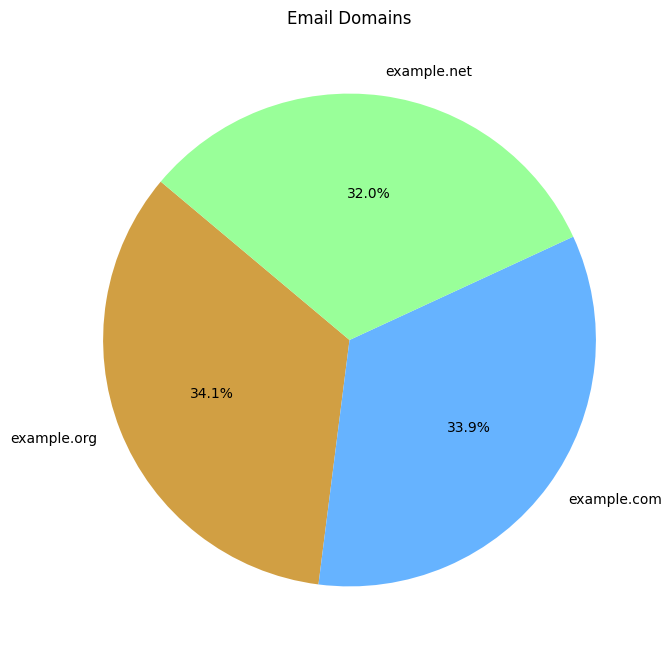

In [25]:
#Import Matplotlib for making neat charts
import matplotlib.pyplot as plt

# Count the occurrences of each domain
domain_counts = data['Domain'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
domain_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=["#d19f43",'#66b3ff','#99ff99']) # This is cool,it allows you to select colour from a pop up
plt.title('Email Domains')
plt.ylabel('')  
plt.show()

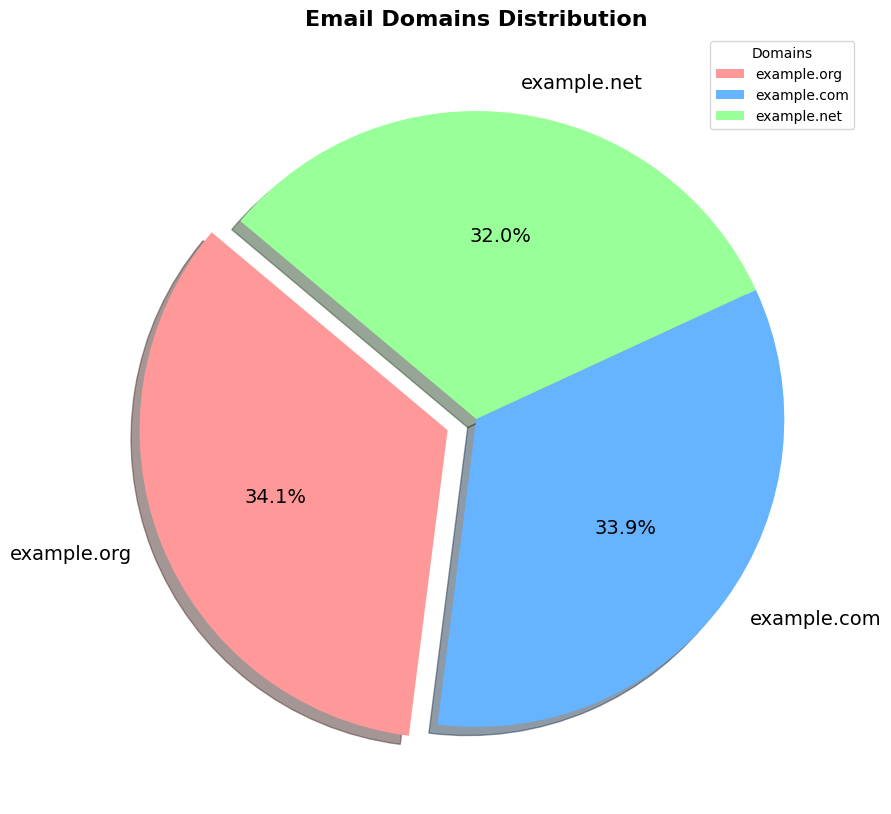

In [30]:
# Play Around with Styling
plt.figure(figsize=(10, 10))
explode = (0.1, 0, 0)  # Explode the largest slice (example.org)
colors = ["#ff9999", "#66b3ff", "#99ff99"]  # Custom colors for the slices

domain_counts.plot(
    kind='pie',
    autopct='%1.1f%%', # Show percentages
    startangle=140, # Rotate the start of the pie chart
    explode=explode, # Explode the largest slice
    colors=colors, # Custom colors
    shadow=True, # Add shadow for 3D effect
    textprops={'fontsize': 14, 'color': 'black'} # Text properties
)

plt.title('Email Domains Distribution', fontsize=16, fontweight='bold')
plt.ylabel('')  # Remove the default y-axis label
plt.legend(labels=domain_counts.index, loc="upper right", fontsize=10, title="Domains")
plt.show()

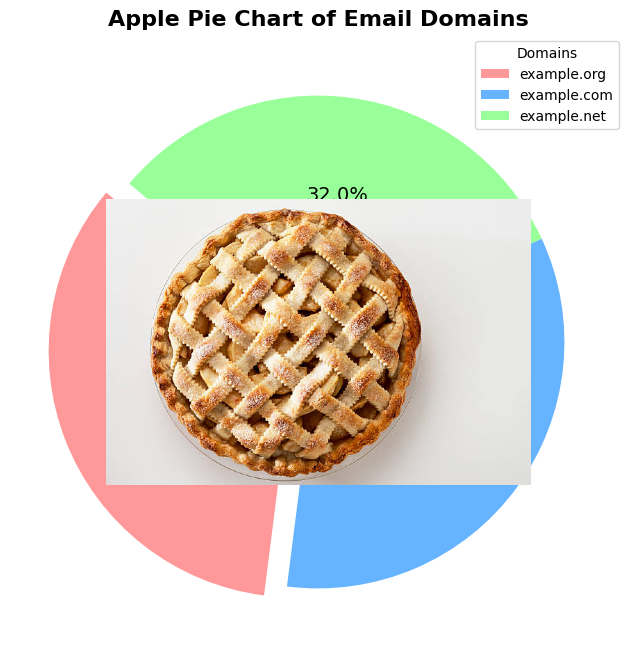

In [36]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import matplotlib.pyplot as plt

# Load an apple pie image
apple_pie_image = Image.open("pie.jpg") 

# Create a pie chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    domain_counts,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    colors=colors,
    textprops={'fontsize': 14, 'color': 'black'}
)

# Add the apple pie image to the center of the pie chart
imagebox = OffsetImage(apple_pie_image, zoom=0.5)
ab = AnnotationBbox(imagebox, (0, 0), frameon=False)
ax.add_artist(ab)

# Customize the chart
plt.title('Apple Pie Chart of Email Domains', fontsize=16, fontweight='bold')
plt.ylabel('')  # Remove the default y-axis label
plt.legend(labels=domain_counts.index, loc="upper right", fontsize=10, title="Domains")
plt.show()

**Note to Self**

Tried to use AI to make the pie chart a literal pie - might come back and try figure this out 